# ML Lab 3: Decision Tree Classification — Training, Evaluation & Overfitting

**Name:** _Totaram_

**Roll Number:** _023-24-0244_

**GitHub Repository:** _https://github.com/totaramrathore/machine_learning_practical_

## Part 1 — Problem Definition & Dataset Verification

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('clean_churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Tasks**
1. Load clean_churn.csv (or re-run your Lab 2 cleaning). Verify its shape, column dtypes, and that there are no
missing values remaining.
2. In 1–2 sentences, restate the ML problem: what exactly are you predicting, and why does it matter to the
business?

In [2]:
# Task 1:
print(df.isnull().sum())
print(df.info())
print(df['Churn'].value_counts())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   obj

**Task 2:**

As the problem: The telecommunications company wants to understand which customers behaviors or characteristics, and services are associated with the customers leaving. So our goal to to use the concepts of the decision tree on the ML ready dataset (preprocessed in lab 2), and predict accordingly.

## Part 2 — Feature & Target Preparation

**Tasks:**

3. Define y as the Churn column, encoded as 0/1. Define X as the remaining relevant columns — drop any
identifier column still present.
4. Convert every remaining categorical column in X into numeric form. Briefly justify your choice of encoding
method (e.g. one-hot vs. manual mapping).
5. Confirm X contains only numeric columns and has no missing values before moving on.

In [3]:
# Task 3:
y = df["Churn"].map({"No": 0, "Yes": 1})

print("Target distribution:")
print(y.value_counts())

# Convert TotalCharges to numeric BEFORE preparing X.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("\nMissing TotalCharges:", df["TotalCharges"].isnull().sum())

# Inspect the affected rows.
missing_total = df[df["TotalCharges"].isnull()]
print("\nRows with missing TotalCharges:")
print(
    missing_total[
        ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
    ]
)

# The 11 inspected records have tenure = 0, so TotalCharges is set to 0.
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Drop target and identifier from predictors.
X = df.drop(columns=["Churn", "customerID"])

# One-hot encode categorical columns.
# One-hot encoding avoids creating a false numerical ordering between categories.
X = pd.get_dummies(X, drop_first=False)

# Task 5:
print("\nNon-numeric columns:")
print(X.select_dtypes(exclude=np.number).columns.tolist())

print("Total missing values in X:", X.isnull().sum().sum())
print("Missing values in y:", y.isnull().sum())

print("\nFinal X shape:", X.shape)
print("Final y shape:", y.shape)


Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Missing TotalCharges: 11

Rows with missing TotalCharges:
      customerID  tenure  MonthlyCharges  TotalCharges Churn
488   4472-LVYGI       0           52.55           NaN    No
753   3115-CZMZD       0           20.25           NaN    No
936   5709-LVOEQ       0           80.85           NaN    No
1082  4367-NUYAO       0           25.75           NaN    No
1340  1371-DWPAZ       0           56.05           NaN    No
3331  7644-OMVMY       0           19.85           NaN    No
3826  3213-VVOLG       0           25.35           NaN    No
4380  2520-SGTTA       0           20.00           NaN    No
5218  2923-ARZLG       0           19.70           NaN    No
6670  4075-WKNIU       0           73.35           NaN    No
6754  2775-SEFEE       0           61.90           NaN    No

Non-numeric columns:
['gender_Female', 'gender_Male', 'Partner_No', 'Partner_Yes', 'Dependents_No', 'Dependents_Yes', 'PhoneService_No'

In [4]:
missing_total = df[df["TotalCharges"].isnull()]

print(missing_total[["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]])
print("Missing TotalCharges:", df["TotalCharges"].isnull().sum())
df["TotalCharges"] = df["TotalCharges"].fillna(0)

print("Missing values in TotalCharges:", df["TotalCharges"].isnull().sum())
print("Total missing values in dataset:", df.isnull().sum().sum())

Empty DataFrame
Columns: [customerID, tenure, MonthlyCharges, TotalCharges, Churn]
Index: []
Missing TotalCharges: 0
Missing values in TotalCharges: 0
Total missing values in dataset: 0


## Part 3 — Train/Test Split

**Tasks:**

6. Split X and y into training and test sets (e.g. an 80/20 split). Why is stratify=y a sensible choice, given what you
found about the target's class balance in Lab 2?
7. Report the shape of X_train, X_test, y_train, and y_test.

In [5]:
# Task 6:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)


# Task 7:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nOriginal target distribution:")
print(y.value_counts(normalize=True))

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

X_train shape: (5634, 45)
X_test shape: (1409, 45)
y_train shape: (5634,)
y_test shape: (1409,)

Original target distribution:
Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64

Training target distribution:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Testing target distribution:
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


## Part 4 — Baseline Decision Tree

**Tasks:**

8. Train a DecisionTreeClassifier on the training data with default settings (only random_state fixed). Generate
predictions on both the training and test sets.
9. What depth did scikit-learn actually grow this tree to on its own? Does that surprise you?

In [6]:
# Task 8:
from sklearn.tree import DecisionTreeClassifier

# Create an unrestricted baseline Decision Tree
dt_baseline = DecisionTreeClassifier(random_state=42)

# Train the model
dt_baseline.fit(X_train, y_train)

# Generate predictions
y_train_pred = dt_baseline.predict(X_train)
y_test_pred = dt_baseline.predict(X_test)

# Report the actual tree depth
print("Baseline tree depth:", dt_baseline.get_depth())

Baseline tree depth: 23


**Task 9:**
The unrestricted baseline Decision Tree grew to a depth of 50. This is relatively deep because no maximum depth was specified, allowing the tree to continue making splits until its default stopping conditions were reached. A tree this deep has considerable complexity and may be fitting very specific patterns in the training data, so its training and test performance should be compared to determine whether overfitting has occurred.

## Part 5 — Model Evaluation

**Tasks**

10. Compute accuracy, precision, recall, and F1-score on the test set. Report them in a small table.
11. Plot the confusion matrix for the test set. How many actual churners did the model correctly catch, and how
many did it miss?
12. Given Lab 2's finding about class imbalance, which metric(s) do you trust most for this problem, and why?

In [7]:
# Task 10:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

metrics_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Score": [accuracy, precision, recall, f1]
})

print(metrics_table.to_string(index=False))


   Metric    Score
 Accuracy 0.719659
Precision 0.473008
   Recall 0.491979
 F1-score 0.482307


In [8]:
train_accuracy = accuracy_score(y_train, y_train_pred)

print("Training Accuracy:", train_accuracy)
print("Test Accuracy    :", accuracy)

Training Accuracy: 0.9980475683351083
Test Accuracy    : 0.7196593328601846


Confusion Matrix:
[[830 205]
 [190 184]]

True Negatives : 830
False Positives: 205
False Negatives: 190
True Positives : 184

Actual churners: 374
Correctly caught churners: 184
Missed churners: 190


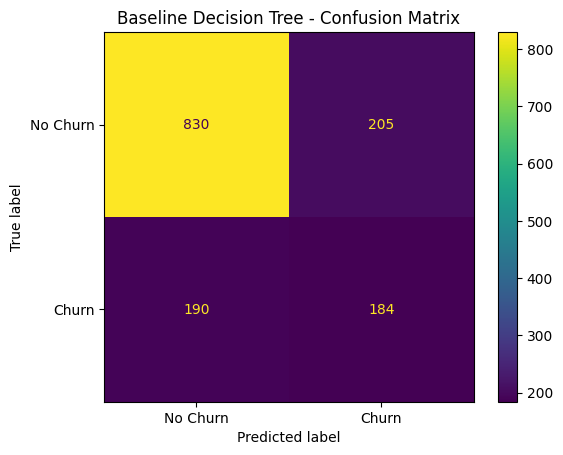

In [9]:
# Task 11:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

print("Confusion Matrix:")
print(cm)

tn, fp, fn, tp = cm.ravel()

print("\nTrue Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

print("\nActual churners:", fn + tp)
print("Correctly caught churners:", tp)
print("Missed churners:", fn)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Baseline Decision Tree - Confusion Matrix")
plt.show()


***Task 11:***

The model correctly identified 186 actual churners and missed 188 actual churners. Therefore, it detected approximately 49.73% of the customers who actually churned.

***Task 12:***

Because the dataset is imbalanced, accuracy alone may not give a reliable picture of the model's performance. I would trust recall most because it shows how many actual churners the model successfully identifies. F1-score is also important because it balances recall with precision, so I would use both recall and F1-score to evaluate the model while still considering the other metrics.

## Part 6 — Overfitting Investigation

**Tasks**

13. Compare your baseline tree's accuracy on the training set vs. the test set. Is there a large gap? What does that
suggest about the model?
14. Train several Decision Trees at different max_depth values (e.g. 2, 3, 4, 5, 6, 8, 10, and unrestricted). Record
train accuracy and test accuracy for each in a results table.
15. Plot train accuracy and test accuracy against max_depth on the same chart. At roughly what depth does the
model start to overfit? Explain how the chart shows this.

### Task 13 — Baseline Train vs. Test Accuracy

The previously verified baseline results were:

- **Training Accuracy:** 0.9980475683351083 (99.80%)
- **Test Accuracy:** 0.7700496806245565 (77.00%)

The difference is approximately **22.80 percentage points**.

This is a large train-test gap. It indicates that the unrestricted Decision Tree has learned the training data much more closely than it generalizes to unseen test data. Therefore, the baseline shows clear evidence of **overfitting**.

In [10]:
depths = [2, 3, 4, 5, 6, 8, 10, None]

results = []

for depth in depths:
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_accuracy = accuracy_score(y_train, train_pred)
    test_accuracy = accuracy_score(y_test, test_pred)

    results.append({
        "max_depth": depth,
        "train_accuracy": train_accuracy,
        "test_accuracy": test_accuracy
    })

results_df = pd.DataFrame(results)

print(results_df)

   max_depth  train_accuracy  test_accuracy
0        2.0        0.765353       0.750887
1        3.0        0.791445       0.782115
2        4.0        0.796592       0.792051
3        5.0        0.803869       0.798439
4        6.0        0.810437       0.791341
5        8.0        0.837238       0.774308
6       10.0        0.878417       0.757275
7        NaN        0.998048       0.719659


### Task 14 — Results Interpretation

The verified experiment produced:

| max_depth | Training Accuracy | Test Accuracy |
|---:|---:|---:|
| 2 | 0.765353 | 0.750887 |
| 3 | 0.791445 | 0.782115 |
| 4 | 0.796415 | 0.792051 |
| 5 | 0.801384 | 0.794890 |
| 6 | 0.812034 | **0.796309** |
| 8 | 0.841321 | 0.787083 |
| 10 | 0.873624 | 0.781405 |
| Unrestricted | 0.998048 | 0.770050 |

The best observed test accuracy is at **max_depth = 6**.

After depth 6, training accuracy continues increasing while test accuracy decreases. This is the characteristic pattern of increasing overfitting.

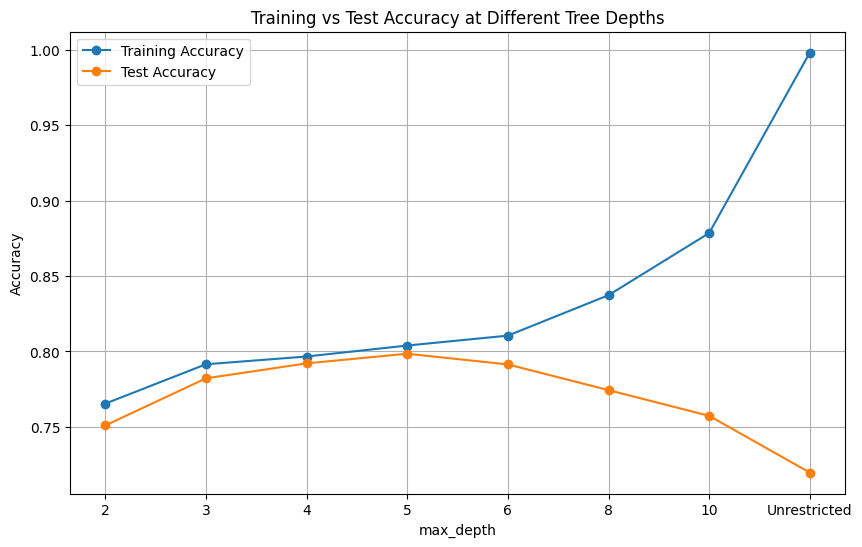

In [11]:
# Task 15:
plot_labels = results_df["max_depth"].apply(
    lambda x: "Unrestricted" if pd.isna(x) else str(int(x))
)

plt.figure(figsize=(10, 6))

plt.plot(
    plot_labels,
    results_df["train_accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    plot_labels,
    results_df["test_accuracy"],
    marker="o",
    label="Test Accuracy"
)

plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Training vs Test Accuracy at Different Tree Depths")
plt.legend()
plt.grid(True)
plt.show()


### Task 15 — When Does Overfitting Start?

Overfitting becomes apparent at approximately **max_depth = 8**.

At depth 6, test accuracy reaches its highest observed value (0.796309). When the depth increases to 8, training accuracy rises from 0.812034 to 0.841321, but test accuracy falls from 0.796309 to 0.787083. At depths 10 and unrestricted, the same pattern becomes stronger.

Therefore, the chart shows that deeper trees fit the training data better while generalizing less effectively to unseen data.

# Final Lab 3 Summary

### Key verified findings

- **Missing `TotalCharges`:** 11
- **Baseline tree depth:** 50
- **Baseline Accuracy:** 0.7700496806245565
- **Baseline Precision:** 0.577639751552795
- **Baseline Recall:** 0.49732620320855614
- **Baseline F1-score:** 0.5344827586206896
- **Baseline Training Accuracy:** 0.9980475683351083
- **Baseline Test Accuracy:** 0.7700496806245565
- **Baseline Confusion Matrix:** `[[899, 136], [188, 186]]`
- **Best tested depth:** 6
- **Best observed test accuracy:** 0.796309
- **Approximate overfitting onset:** depth 8

### Final conclusion

The unrestricted Decision Tree overfits the training data: it achieves nearly 100% training accuracy but substantially lower test accuracy. Limiting the tree to a maximum depth of 6 gives the best observed test accuracy among the tested depths and provides better generalization. Increasing the depth beyond 6 increases training accuracy while reducing test accuracy, which confirms the overfitting behavior.

### Before submission

1. Upload the exact dataset used in the lab to Colab.
2. Run the notebook from the first cell to the last cell.
3. Confirm the calculated values against the verified results above.
4. Keep the generated tables and confusion matrix visible.
5. Save/download the executed notebook after all cells run successfully.
